## What is SGDRegressor?

**SGDRegressor** is a linear regression model trained using **Stochastic Gradient Descent** optimization.

Instead of computing gradients on the **entire dataset**, it updates weights **one sample at a time**, making it efficient for **large-scale datasets**.

## When to Use SGDRegressor

Use it when:

* Dataset is **very large**
* **Online learning** is required
* **Streaming data**
* Memory is limited
* Need **fast training**

Common in:

* Recommender systems
* Ad click prediction
* Real-time ML systems

##  Advantages

- 1️. Very **fast training**
- 2. Works well with **large datasets**
- 3. Supports **online learning** (`partial_fit`)
- 4. Works with **regularization (L1/L2)**


##  Disadvantages

- 1️. Requires **feature scaling**
- 2️. Sensitive to **learning rate**
- 3️.  May converge **slowly or unstably**
- 4️. Less accurate than complex models for small datasets

##  Important Hyperparameters

### 1. `loss`

Loss function.

Examples:

```
"squared_error" → standard regression
"huber" → robust to outliers
```


### 2️. `penalty`

Regularization.

```
l2 → Ridge
l1 → Lasso
elasticnet → L1 + L2
```

### 3️. `alpha`

Regularization strength.

```
smaller alpha → less regularization
larger alpha → stronger regularization
```


### 4️. `learning_rate`

Controls step size.

Options:

```
constant
optimal
adaptive
```


### 5️. `max_iter`

Maximum number of training iterations.


## Practical Tuning Tips

### Tip 1 — Always Scale Features

```
StandardScaler
MinMaxScaler
```


### Tip 2 — Tune Learning Rate

Bad learning rate → divergence.

Start with:

```
learning_rate = "optimal"
```


### Tip 3 — Use Early Stopping

```
early_stopping=True
```

Prevents overfitting.


### Tip 4 — Use ElasticNet Regularization

Often performs better.

```
penalty="elasticnet"
l1_ratio=0.5
```


### Tip 5 — Use Pipelines

Prevents data leakage.


## Real-World Applications

SGDRegressor is used in:

* **Large-scale recommendation systems**
* **Online advertising prediction**
* **Stock price regression**
* **Real-time ML pipelines**



**Importing Libraries**

In [1]:
# Core libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Model
from sklearn.linear_model import SGDRegressor

# Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Settings
sns.set(style="whitegrid")

**Load dataset**

In [2]:
# Load California Housing dataset
data = fetch_california_housing()

In [3]:
# Convert to DataFrame
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="Target")

# Preview data
X.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


**Exploratory Data Analysis (EDA)**

In [4]:
# Dataset shape
print("Dataset shape:", X.shape)

# Summary statistics
X.describe()

Dataset shape: (20640, 8)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000


**Data Cleaning**

In [5]:
# Check missing values
X.isnull().sum()

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
dtype: int64

In [6]:
# Fill missing values
X = X.fillna(X.mean())

**Feature Engineering**

In [7]:
# Example feature engineering

X["Rooms_per_Household"] = X["AveRooms"] / X["HouseAge"]
X["Population_per_Household"] = X["Population"] / X["AveOccup"]

X.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Rooms_per_Household,Population_per_Household
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,0.170345,126.0
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,0.297054,1138.0
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,0.159387,177.0
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,0.111872,219.0
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,0.120805,259.0


**Train-Test Split**

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [9]:
print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

Training set size: (16512, 10)
Test set size: (4128, 10)


**Model Pipeline**

In [10]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SGDRegressor(random_state=42))
])

**Hyperparameter Tuning with GridSearchCV**

In [11]:
param_grid = {
    "model__loss": ["squared_error", "huber"],
    "model__penalty": ["l2", "l1", "elasticnet"],
    "model__alpha": [0.0001, 0.001, 0.01],
    "model__learning_rate": ["constant", "optimal"],
    "model__max_iter": [1000, 2000]
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'model__alpha': 0.0001, 'model__learning_rate': 'constant', 'model__loss': 'huber', 'model__max_iter': 1000, 'model__penalty': 'l1'}


**Train Final Model**

In [12]:
best_model = grid.best_estimator_

best_model.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 SGDRegressor(learning_rate='constant', loss='huber',
                              penalty='l1', random_state=42))])

**Model Prediction**

In [13]:
# Predictions
y_pred = best_model.predict(X_test)

**Model Evaluation**

In [14]:
# Regression Metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [15]:
print("Evaluation Metrics:")
print("MSE :", mse)
print("RMSE:", rmse)
print("MAE :", mae)
print("R2  :", r2)

Evaluation Metrics:
MSE : 0.5228114667284051
RMSE: 0.7230570286833571
MAE : 0.5009296951946071
R2  : 0.6010318340231231


**Prediction vs Actual Visualization**

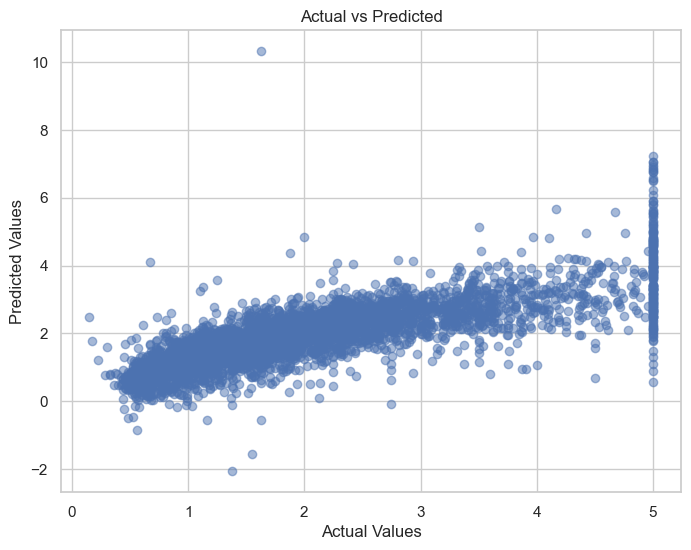

In [16]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")

plt.show()

**Residual Plot**

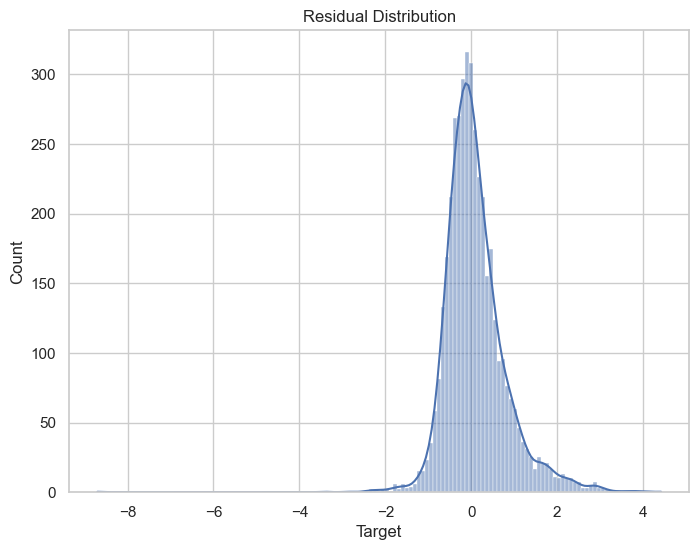

In [17]:
residuals = y_test - y_pred

plt.figure(figsize=(8,6))
sns.histplot(residuals, kde=True)

plt.title("Residual Distribution")
plt.show()

**Learning Curve**

In [18]:
train_sizes, train_scores, test_scores = learning_curve(
    best_model,
    X_train,
    y_train,
    cv=5,
    scoring="r2",
    n_jobs=1
)

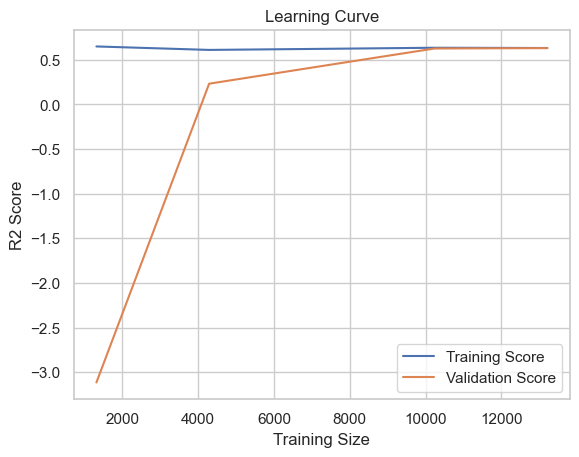

In [19]:
train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.plot(train_sizes, train_mean, label="Training Score")
plt.plot(train_sizes, test_mean, label="Validation Score")

plt.xlabel("Training Size")
plt.ylabel("R2 Score")
plt.title("Learning Curve")
plt.legend()

plt.show()